# Qwen2.5-Coder 14B to 3B: Knowledge Distillation with GKD + QLoRA

**Goal:** Distill the code-generation capabilities of `Qwen2.5-Coder-14B-Instruct` (teacher) into `Qwen2.5-Coder-3B-Instruct` (student) using **Generalized Knowledge Distillation (GKD)** on top of **QLoRA**, fitting both models on a single NVIDIA A100 80 GB GPU.

## Experiment Configuration

| Component | Detail |
|---|---|
| **Teacher** | `Qwen/Qwen2.5-Coder-14B-Instruct` -- frozen, 4-bit NF4 |
| **Student** | `Qwen/Qwen2.5-Coder-3B-Instruct` + LoRA (r=16, alpha=32) |
| **Distillation** | TRL `DistillationTrainer` with GKD (lambda=0.25, beta=0.5) |
| **Dataset** | `iamtarun/python_code_instructions_18k_alpaca` (~18K Python instruction-code pairs) |
| **Training** | 300 optimizer steps, effective batch size 32, cosine LR 1.5e-4 |
| **Hardware** | Google Colab A100 80 GB, ~5 hours wall time |

## Why 14B to 3B?

- **~4.7x fewer parameters** -- dramatically lower serving cost and GPU footprint
- The 3B student starts from `Qwen2.5-Coder-3B-Instruct`, a strong pre-trained base; GKD specialises its output distribution toward the teacher rather than training from scratch
- Only LoRA adapters are trained (less than 25 M params, less than 1% of the student) -- lightweight artifact, easy to merge or swap
- A 3B model can run on consumer hardware (RTX 3090/4090, 24 GB VRAM) in full precision, making distilled quality accessible outside datacenter setups

## Architecture Comparison

| Property | Teacher (14B) | Student (3B) | Ratio (S/T) |
|---|---:|---:|---:|
| Total parameters | ~14.77 B | ~3.09 B | **0.21x** |
| 4-bit storage footprint | ~7.4 GB | ~1.6 GB | **0.22x** |
| Trainable params (LoRA) | frozen | ~25 M | -- |

## GKD Loss Formulation

GKD interpolates between forward-KL and reverse-KL divergences with a Jensen-Shannon-style blend:

```
L_GKD = lambda * L_on_policy + (1-lambda) * L_teacher_forced
      where L = beta * KL(student || teacher) + (1-beta) * KL(teacher || student)
```

With **lambda=0.25** and **beta=0.5**:
- 25% of each batch uses student-generated (on-policy) sequences -- reduces exposure bias
- 75% uses teacher-forced sequences -- maintains training stability at 300 steps
- beta=0.5 gives symmetric Jensen-Shannon divergence, balancing mode-covering and mode-seeking behaviour

## Training Hyperparameters

| Hyperparameter | Value |
|---|---|
| LoRA rank (r) | 16 |
| LoRA alpha | 32 |
| LoRA dropout | 0.05 |
| Target modules | q/k/v/o_proj, gate/up/down_proj |
| Optimizer | paged_adamw_8bit |
| Learning rate | 1.5e-4 |
| LR schedule | Cosine with warmup |
| Max steps | 300 |
| Per-device batch size | 16 |
| Gradient accumulation | 2 (effective batch = 32) |
| Precision | bf16 |
| GKD lambda (on-policy fraction) | 0.25 |
| GKD beta (KL interpolation) | 0.5 |


## Distillation Results: HumanEval Benchmark

The distilled student was evaluated on the full **HumanEval** benchmark (164 Python programming tasks) in two configurations:
- **Base**: `Qwen2.5-Coder-3B-Instruct` without distillation (the pre-trained student checkpoint)
- **Merged**: the same 3B model with the GKD-trained LoRA adapter merged into its weights

### pass@1 Summary

| Model | Passed | Total | pass@1 |
|---|---:|---:|---:|
| Base (Qwen2.5-Coder-3B-Instruct) | 133 | 164 | **81.1%** |
| Merged (distilled, 300 steps) | 137 | 164 | **83.5%** |
| **Delta** | +4 | -- | **+2.44 pp** |

The 300-step GKD run (~9,600 training examples seen at effective batch 32) yields a **+2.44 percentage-point lift** over the un-distilled 3B checkpoint with no increase in model size or inference cost.

### Task-level Analysis

**Tasks gained by distillation** (base failed, merged passed -- 11 tasks):

| Task ID | Description |
|---|---|
| HumanEval/26 | Remove elements occurring more than once, preserving first-occurrence order |
| HumanEval/64 | Vowel count with y counted only at word-end |
| HumanEval/75 | Check if a number is the product of exactly 3 prime factors |
| HumanEval/89 | Caesar cipher with uppercase/lowercase preservation |
| HumanEval/93 | Encode: swap case then shift vowels forward by 2 positions |
| HumanEval/95 | Validate dict keys are uniformly all-lowercase or all-uppercase |
| HumanEval/110 | Exchange list elements to make all elements in first list even |
| HumanEval/123 | Return odd elements of the Collatz sequence |
| HumanEval/124 | Valid date string parsing (DD-MM-YYYY format) |
| HumanEval/125 | Split words on whitespace or comma |
| HumanEval/135 | Return largest and smallest integers from a list |

**Tasks lost by distillation** (base passed, merged failed -- 7 tasks):

| Task ID | Description |
|---|---|
| HumanEval/10 | Make palindrome (find shortest completion) |
| HumanEval/46 | fib4 sequence (4-term Fibonacci variant) |
| HumanEval/99 | Closest integer with bankers rounding |
| HumanEval/103 | Rounded mean of two integers |
| HumanEval/141 | File type check by allowed extension list |
| HumanEval/154 | Cyclic rotation check |
| HumanEval/159 | Eat function (food consumed and remaining) |

Net change: **+4 tasks** solved (11 gained minus 7 lost).

### Key Observations

1. **Gains concentrate on reasoning-heavy string and number tasks** -- tasks like /89 (Caesar cipher with case logic), /93 (compound encode), /124 (date parsing) require multi-step conditional logic that the teacher transfers effectively across the 14B to 3B capacity gap.
2. **Regressions cluster on precise numeric/sequence edge cases** -- HumanEval/99 (bankers rounding), /46 (fib4 base cases), /103 (rounded mean) suggest the 300-step run introduces slight distribution shift away from exact arithmetic corner cases that the 3B base handled correctly.
3. **20 tasks fail in both models** -- these appear to be at or beyond the capacity ceiling of a 3B model at this training budget; longer training or a higher LoRA rank may help.
4. **+2.44 pp from 300 steps is a meaningful signal** -- extrapolating to 3 full epochs (~1,656 steps) would expose the student to ~6x more data, likely pushing further gains before plateau.


In [1]:
import json

with open('results/humaneval_results_qwen3B.json') as f:
    data = json.load(f)

base_results   = {x['task_id']: x['passed'] for x in data['base']}
merged_results = {x['task_id']: x['passed'] for x in data['merged']}
all_ids = sorted(base_results.keys(), key=lambda x: int(x.split('/')[1]))

gained    = [t for t in all_ids if not base_results[t] and merged_results[t]]
lost      = [t for t in all_ids if base_results[t] and not merged_results[t]]
both_fail = [t for t in all_ids if not base_results[t] and not merged_results[t]]
both_pass = [t for t in all_ids if base_results[t] and merged_results[t]]

base_pct   = sum(base_results.values()) / len(all_ids) * 100
merged_pct = sum(merged_results.values()) / len(all_ids) * 100

print(f'Both pass : {len(both_pass):>3}')
print(f'Gained    : {len(gained):>3}  {gained}')
print(f'Lost      : {len(lost):>3}  {lost}')
print(f'Both fail : {len(both_fail):>3}')
print()
print(f'Base   pass@1 : {sum(base_results.values())}/{len(all_ids)} = {base_pct:.2f}%')
print(f'Merged pass@1 : {sum(merged_results.values())}/{len(all_ids)} = {merged_pct:.2f}%')
delta_pp = merged_pct - base_pct
delta_n  = sum(merged_results.values()) - sum(base_results.values())
print(f'Delta         : +{delta_n} tasks  ({delta_pp:+.2f} pp)')


Both pass : 126
Gained    :  11  ['HumanEval/26', 'HumanEval/64', 'HumanEval/75', 'HumanEval/89', 'HumanEval/93', 'HumanEval/95', 'HumanEval/110', 'HumanEval/123', 'HumanEval/124', 'HumanEval/125', 'HumanEval/135']
Lost      :   7  ['HumanEval/10', 'HumanEval/46', 'HumanEval/99', 'HumanEval/103', 'HumanEval/141', 'HumanEval/154', 'HumanEval/159']
Both fail :  20

Base   pass@1 : 133/164 = 81.10%
Merged pass@1 : 137/164 = 83.54%
Delta         : +4 tasks  (+2.44 pp)


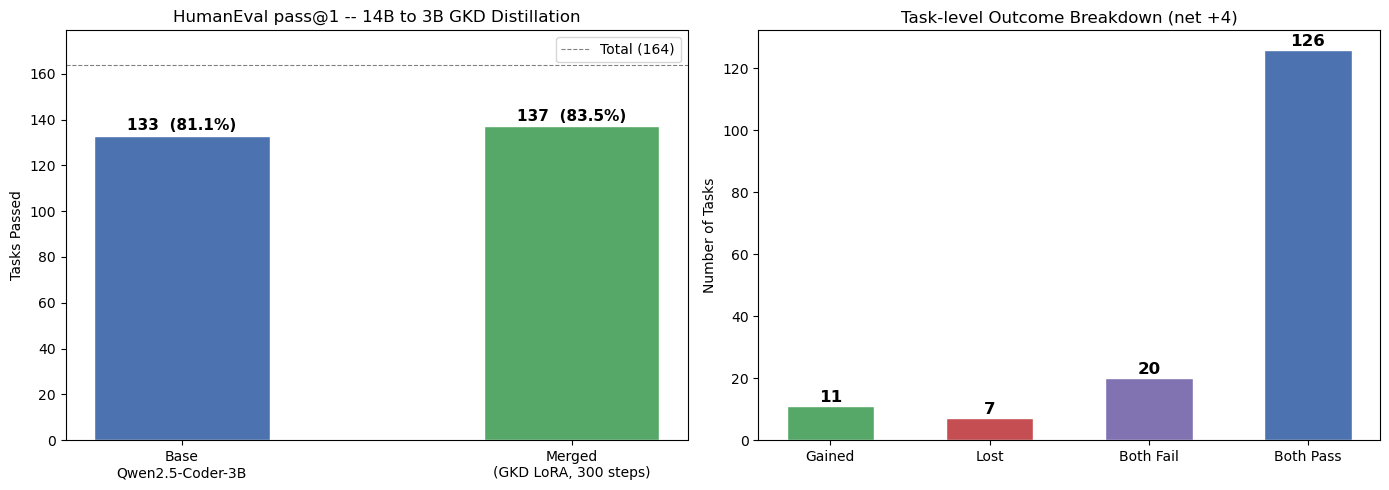

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
models = ['Base\nQwen2.5-Coder-3B', 'Merged\n(GKD LoRA, 300 steps)']
counts = [133, 137]
total  = 164
colors = ['#4C72B0', '#55A868']
bars = ax.bar(models, counts, color=colors, width=0.45, edgecolor='white')
ax.axhline(total, color='grey', linestyle='--', linewidth=0.8, label=f'Total ({total})')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{c}  ({c/total*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, total + 15)
ax.set_ylabel('Tasks Passed')
ax.set_title('HumanEval pass@1 -- 14B to 3B GKD Distillation')
ax.legend()

ax2 = axes[1]
cats = ['Gained', 'Lost', 'Both Fail', 'Both Pass']
vals = [len(gained), len(lost), len(both_fail), len(both_pass)]
clrs = ['#55A868', '#C44E52', '#8172B2', '#4C72B0']
b2 = ax2.bar(cats, vals, color=clrs, width=0.55, edgecolor='white')
for bar, v in zip(b2, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Tasks')
ax2.set_title(f'Task-level Outcome Breakdown (net +{len(gained)-len(lost)})')

plt.tight_layout()
plt.savefig('results/humaneval_14b_3b_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Next Steps

1. **Train longer** -- bump `max_steps` to ~1,000-2,000 (or 3 full epochs) and monitor the HumanEval curve for diminishing returns.
2. **Tune lambda and beta** -- the current lambda=0.25 (mostly teacher-forced) is conservative for 300 steps; values around lambda=0.5-0.75 increase on-policy exposure and may reduce regressions on edge-case tasks.
3. **Investigate regressions** -- the 7 lost tasks (bankers rounding, fib4, cyclic rotation, etc.) are good candidates for targeted few-shot examples or a higher LoRA rank.
4. **Add a code-aware eval callback** -- wire pass@1 into the training loop (evaluate on a held-out 10% of HumanEval every 50 steps) to detect regressions early rather than post-hoc.
5. **Benchmark inference latency** -- measure tokens/sec and VRAM for the merged 3B vs the 14B teacher on identical prompts to quantify the serving cost reduction.
6. **Push adapter to Hub** -- publish the merged LoRA as `Harsha901/qwen2.5-coder-3b-distilled-from-14b` for reproducibility.
